## 02 Customer Segmentation

Build customer segments from H&M transaction behavior and customer metadata.

Output:

- customer segments
- segment strategies (for LLM use)
- cluster summary


In [32]:
import os
import pandas as pd
import numpy as np

import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

#### Load processed data


In [2]:
PROCESSED_DIR = "../data/processed/hm"

customers = pd.read_csv(os.path.join(PROCESSED_DIR, "customers.csv"))
articles = pd.read_csv(os.path.join(PROCESSED_DIR, "articles.csv"))
transactions = pd.read_csv(os.path.join(PROCESSED_DIR, "transactions.csv"))

transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

print(customers.shape)
print(articles.shape)
print(transactions.shape)

(1371980, 8)
(105542, 30)
(500000, 5)


In [3]:
articles.head()

,article_id,product_code,product_name,product_type_no,product_type,product_group,graphical_appearance_no,graphical_appearance,colour_group_code,color_group,...,section_no,section,garment_group_no,garment_group,description,image_path,image_exists,product_purchase_count,unique_customer_count,avg_selling_price
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,../data/raw/hm/images/010/0108775015.jpg,True,175.0,172.0,0.008139
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,../data/raw/hm/images/010/0108775044.jpg,True,116.0,116.0,0.008196
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,../data/raw/hm/images/010/0108775051.jpg,True,2.0,2.0,0.004559
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde...",../data/raw/hm/images/011/0110065001.jpg,True,19.0,19.0,0.020756
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde...",../data/raw/hm/images/011/0110065002.jpg,True,11.0,11.0,0.016932


In [4]:
customers.head()

,customer_id,fashion_news_binary,is_active,club_member_status,fashion_news_frequency,age,postal_code,age_group
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,0.0,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...,Adult
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0.0,0.0,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...,Young Adult
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0.0,0.0,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...,Gen Z
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,0.0,0.0,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...,Mature
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...,Mature


In [5]:
transactions.head()

,transaction_date,customer_id,article_id,price,sales_channel_id
0,2019-09-13,215895f90002eb3d1a04bd603513c8e85e6002ef08f136...,786586001,0.022017,1
1,2019-02-23,7b183268e3a4623b80d5325ec4a20a0af0edff7bcb1748...,658911001,0.028797,2
2,2019-07-17,2eb7412239a90c0570cd3d1bf0492856ae5b59058b1ea6...,759326005,0.050831,2
3,2019-05-16,74f162e5a170fd57207aa2a7d5c58479ee9de903b2a277...,737137004,0.027102,1
4,2019-08-10,aab9306ee28c4db494003955f80355e540b01480ab35cf...,785931001,0.050831,2


#### Merge product context into transactions

This allows us to understand not just how much a customer buys, but also what kind of products they buy.


In [6]:
txn = transactions.merge(
    articles[
        [
            "article_id",
            "product_type",
            "product_group",
            "color_group",
            "index_group",
            "garment_group",
            "avg_selling_price"
        ]
    ],
    on="article_id",
    how="left"
)

txn.head()

,transaction_date,customer_id,article_id,price,sales_channel_id,product_type,product_group,color_group,index_group,garment_group,avg_selling_price
0,2019-09-13,215895f90002eb3d1a04bd603513c8e85e6002ef08f136...,786586001,0.022017,1,Leggings/Tights,Garment Lower body,Black,Baby/Children,Jersey Fancy,0.019414
1,2019-02-23,7b183268e3a4623b80d5325ec4a20a0af0edff7bcb1748...,658911001,0.028797,2,Pyjama set,Nightwear,Dark Blue,Ladieswear,"Under-, Nightwear",0.028797
2,2019-07-17,2eb7412239a90c0570cd3d1bf0492856ae5b59058b1ea6...,759326005,0.050831,2,Swimsuit,Swimwear,Dark Orange,Ladieswear,Swimwear,0.045862
3,2019-05-16,74f162e5a170fd57207aa2a7d5c58479ee9de903b2a277...,737137004,0.027102,1,Blouse,Garment Upper body,Dark Green,Ladieswear,Blouses,0.022032
4,2019-08-10,aab9306ee28c4db494003955f80355e540b01480ab35cf...,785931001,0.050831,2,Trousers,Garment Lower body,White,Ladieswear,Trousers,0.046932


#### Build customer behavior features

These features describe each customer’s shopping behavior.


In [7]:
snapshot_date = txn["transaction_date"].max() + pd.Timedelta(days=1)

customer_behavior = (
    txn.groupby("customer_id")
    .agg(
        total_transactions=("article_id", "count"),
        unique_products=("article_id", "nunique"),
        total_spend=("price", "sum"),
        avg_price=("price", "mean"),
        max_price=("price", "max"),
        first_purchase_date=("transaction_date", "min"),
        last_purchase_date=("transaction_date", "max")
    )
    .reset_index()
)

# Days since last purchase
customer_behavior["days_since_last_purchase"] = (
    snapshot_date - customer_behavior["last_purchase_date"]
).dt.days

# Customer lifetime in days
customer_behavior["customer_lifetime_days"] = (
    customer_behavior["last_purchase_date"] - customer_behavior["first_purchase_date"]
).dt.days + 1

# Purchase frequency (transactions per day)
customer_behavior["purchase_frequency"] = (
    customer_behavior["total_transactions"] / customer_behavior["customer_lifetime_days"]
)

customer_behavior.head()

,customer_id,total_transactions,unique_products,total_spend,avg_price,max_price,first_purchase_date,last_purchase_date,days_since_last_purchase,customer_lifetime_days,purchase_frequency
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,1,1,0.012695,0.012695,0.012695,2019-07-25,2019-07-25,426,1,1.000000
1,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1,1,0.044475,0.044475,0.044475,2019-10-01,2019-10-01,358,1,1.000000
2,0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d...,1,1,0.022017,0.022017,0.022017,2019-10-22,2019-10-22,337,1,1.000000
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,2,2,0.032847,0.016424,0.017610,2018-09-20,2020-04-11,165,570,0.003509
4,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,2,2,0.040932,0.020466,0.025407,2020-06-21,2020-08-17,37,58,0.034483


#### Preference Features

Finds the most common value for each customer. So if a customer mostly buys womenswear and black items, we capture that. This helps make segments more explainable later.


In [8]:
def get_top_value(df, group_col, value_col, output_col):
    return (
        df.groupby([group_col, value_col])
        .size()
        .reset_index(name="count")
        .sort_values([group_col, "count"], ascending=[True, False])
        .drop_duplicates(group_col)
        [[group_col, value_col]]
        .rename(columns={value_col: output_col})
    )

favorite_product_group = get_top_value(
    txn, "customer_id", "product_group", "favorite_product_group"
)

favorite_index_group = get_top_value(
    txn, "customer_id", "index_group", "favorite_index_group"
)

favorite_garment_group = get_top_value(
    txn, "customer_id", "garment_group", "favorite_garment_group"
)

favorite_color = get_top_value(
    txn, "customer_id", "color_group", "favorite_color"
)

In [9]:

customer_features = customer_behavior.copy()

for feature_df in [
    favorite_product_group,
    favorite_index_group,
    favorite_garment_group,
    favorite_color
]:
    customer_features = customer_features.merge(feature_df, on="customer_id", how="left")

customer_features.head()

,customer_id,total_transactions,unique_products,total_spend,avg_price,max_price,first_purchase_date,last_purchase_date,days_since_last_purchase,customer_lifetime_days,purchase_frequency,favorite_product_group,favorite_index_group,favorite_garment_group,favorite_color
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,1,1,0.012695,0.012695,0.012695,2019-07-25,2019-07-25,426,1,1.000000,Garment Upper body,Ladieswear,Blouses,Black
1,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1,1,0.044475,0.044475,0.044475,2019-10-01,2019-10-01,358,1,1.000000,Garment Upper body,Ladieswear,Outdoor,Black
2,0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d...,1,1,0.022017,0.022017,0.022017,2019-10-22,2019-10-22,337,1,1.000000,Garment Upper body,Divided,Jersey Basic,Black
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,2,2,0.032847,0.016424,0.017610,2018-09-20,2020-04-11,165,570,0.003509,Garment Upper body,Divided,Knitwear,Black
4,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,2,2,0.040932,0.020466,0.025407,2020-06-21,2020-08-17,37,58,0.034483,Garment Lower body,Divided,Jersey Basic,Black


#### Price Sensitivity Features

Finds what percentage of this customer’s purchases are cheap / expensive items.

This helps separate Budget Shoppers vs Premium Shoppers.


In [10]:
low_price_threshold = txn["price"].quantile(0.25)
high_price_threshold = txn["price"].quantile(0.75)

txn["is_low_price"] = txn["price"] <= low_price_threshold
txn["is_high_price"] = txn["price"] >= high_price_threshold

price_features = (
    txn.groupby("customer_id")
    .agg(
        low_price_purchase_ratio=("is_low_price", "mean"),
        high_price_purchase_ratio=("is_high_price", "mean")
    )
    .reset_index()
)

customer_features = customer_features.merge(price_features, on="customer_id", how="left")

customer_features.head()

,customer_id,total_transactions,unique_products,total_spend,avg_price,max_price,first_purchase_date,last_purchase_date,days_since_last_purchase,customer_lifetime_days,purchase_frequency,favorite_product_group,favorite_index_group,favorite_garment_group,favorite_color,low_price_purchase_ratio,high_price_purchase_ratio
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,1,1,0.012695,0.012695,0.012695,2019-07-25,2019-07-25,426,1,1.000000,Garment Upper body,Ladieswear,Blouses,Black,1.0,0.0
1,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1,1,0.044475,0.044475,0.044475,2019-10-01,2019-10-01,358,1,1.000000,Garment Upper body,Ladieswear,Outdoor,Black,0.0,1.0
2,0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d...,1,1,0.022017,0.022017,0.022017,2019-10-22,2019-10-22,337,1,1.000000,Garment Upper body,Divided,Jersey Basic,Black,0.0,0.0
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,2,2,0.032847,0.016424,0.017610,2018-09-20,2020-04-11,165,570,0.003509,Garment Upper body,Divided,Knitwear,Black,0.5,0.0
4,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,2,2,0.040932,0.020466,0.025407,2020-06-21,2020-08-17,37,58,0.034483,Garment Lower body,Divided,Jersey Basic,Black,0.5,0.0


#### Add Customer Metadata

Adds customer-level information. Now each customer has both behavioral features and profile metadata.


In [11]:
customer_features = customer_features.merge(
    customers[
        [
            "customer_id",
            "fashion_news_binary",
            "is_active",
            "club_member_status",
            "fashion_news_frequency",
            "age",
            "age_group"
        ]
    ],
    on="customer_id",
    how="left"
)

customer_features.head()

,customer_id,total_transactions,unique_products,total_spend,avg_price,max_price,first_purchase_date,last_purchase_date,days_since_last_purchase,customer_lifetime_days,...,favorite_garment_group,favorite_color,low_price_purchase_ratio,high_price_purchase_ratio,fashion_news_binary,is_active,club_member_status,fashion_news_frequency,age,age_group
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,1,1,0.012695,0.012695,0.012695,2019-07-25,2019-07-25,426,1,...,Blouses,Black,1.0,0.0,0.0,0.0,ACTIVE,NONE,49.0,Adult
1,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1,1,0.044475,0.044475,0.044475,2019-10-01,2019-10-01,358,1,...,Outdoor,Black,0.0,1.0,1.0,1.0,ACTIVE,Regularly,52.0,Mature
2,0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d...,1,1,0.022017,0.022017,0.022017,2019-10-22,2019-10-22,337,1,...,Jersey Basic,Black,0.0,0.0,0.0,0.0,ACTIVE,NONE,20.0,Gen Z
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,2,2,0.032847,0.016424,0.017610,2018-09-20,2020-04-11,165,570,...,Knitwear,Black,0.5,0.0,1.0,1.0,ACTIVE,Regularly,32.0,Young Adult
4,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,2,2,0.040932,0.020466,0.025407,2020-06-21,2020-08-17,37,58,...,Jersey Basic,Black,0.5,0.0,1.0,1.0,ACTIVE,Regularly,56.0,Mature


#### Clustering Features

Chooses which numeric features will be used for KMeans.


In [12]:
clustering_features = [
    "total_transactions",
    "unique_products",
    "total_spend",
    "avg_price",
    "max_price",
    "days_since_last_purchase",
    "customer_lifetime_days",
    "purchase_frequency",
    "low_price_purchase_ratio",
    "high_price_purchase_ratio",
    "fashion_news_binary",
    "is_active",
    "age"
]

cluster_df = customer_features[["customer_id"] + clustering_features].copy()
cluster_df[clustering_features] = cluster_df[clustering_features].fillna(0)

In [13]:

# Scale features (since KMeans is distance-based)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[clustering_features])
X_scaled.shape

(317897, 13)

#### Choose Number of Clusters


In [14]:
k_values = range(2, 9)

results = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    
    results.append({
        "k": k,
        "inertia": model.inertia_,
        # "silhouette_score": silhouette_score(X_scaled, labels)
    })

cluster_eval = pd.DataFrame(results)
cluster_eval

,k,inertia
0,2,3.155153e+06
1,3,2.583315e+06
2,4,2.244237e+06
3,5,2.003553e+06
4,6,1.849691e+06
5,7,1.702090e+06
6,8,1.559887e+06


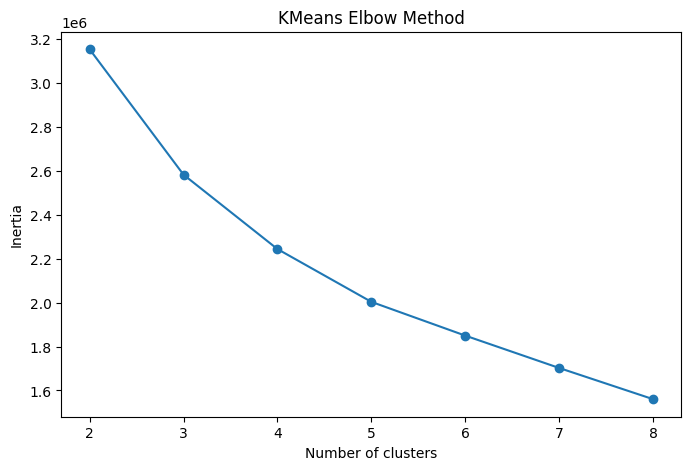

In [15]:
# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(cluster_eval["k"], cluster_eval["inertia"], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("KMeans Elbow Method")
plt.show()

The elbow plot shows a smooth decrease in inertia without a clear “elbow” point, showing that customer behavior does not form sharply separated clusters.

I chose k=5 because the improvement starts to level off around that point, and it gives us a reasonable number of segments that are still easy to interpret for marketing use.


#### Train Final Segmentation Model


In [16]:
FINAL_K = 5

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
customer_features["cluster"] = kmeans.fit_predict(X_scaled)

customer_features["cluster"].value_counts().sort_index()

cluster
0    72231
1    98429
2    65464
3    67830
4    13943
Name: count, dtype: int64

#### Cluster Profiles

This helps we understand what each segment means.


In [17]:
# Creates a summary table for each cluster
cluster_summary = (
    customer_features.groupby("cluster")
    .agg(
        customer_count=("customer_id", "count"),
        avg_total_transactions=("total_transactions", "mean"),
        avg_unique_products=("unique_products", "mean"),
        avg_total_spend=("total_spend", "mean"),
        avg_price=("avg_price", "mean"),
        avg_days_since_last_purchase=("days_since_last_purchase", "mean"),
        avg_purchase_frequency=("purchase_frequency", "mean"),
        avg_low_price_ratio=("low_price_purchase_ratio", "mean"),
        avg_high_price_ratio=("high_price_purchase_ratio", "mean"),
        avg_age=("age", "mean"),
        active_rate=("is_active", "mean"),
        fashion_news_rate=("fashion_news_binary", "mean")
    )
    .reset_index()
)

cluster_summary

,cluster,customer_count,avg_total_transactions,avg_unique_products,avg_total_spend,avg_price,avg_days_since_last_purchase,avg_purchase_frequency,avg_low_price_ratio,avg_high_price_ratio,avg_age,active_rate,fashion_news_rate
0,0,72231,1.084617,1.081738,0.051596,0.047527,378.862995,0.997101,0.001796,0.985133,37.185156,0.368775,0.376016
1,1,98429,1.084416,1.081013,0.019773,0.018303,373.526278,1.006477,0.371732,0.003942,34.907852,0.000000,0.007671
2,2,65464,1.119592,1.116980,0.020007,0.017948,364.727652,0.968784,0.398367,0.006155,36.023830,0.993141,1.000000
3,3,67830,2.478387,2.470691,0.065227,0.026766,216.742857,0.017329,0.236013,0.307077,35.731137,0.424134,0.430562
4,4,13943,5.272682,5.238973,0.179844,0.036758,147.868393,0.015784,0.165385,0.451131,37.067561,0.494944,0.498888


In [18]:
# Show top categorical traits by cluster
for col in [
    "age_group",
    "favorite_product_group",
    "favorite_index_group",
    "favorite_garment_group",
    "favorite_color",
    "fashion_news_frequency"
]:
    display(
        customer_features
        .groupby(["cluster", col])
        .size()
        .reset_index(name="count")
        .sort_values(["cluster", "count"], ascending=[True, False])
        .groupby("cluster")
        .head(3)
    )

,cluster,age_group,count
3,0,Young Adult,24179
2,0,Mature,18000
0,0,Adult,15034
7,1,Young Adult,36323
5,1,Gen Z,23346
4,1,Adult,20872
11,2,Young Adult,18879
9,2,Gen Z,17899
10,2,Mature,14688
15,3,Young Adult,26250


,cluster,favorite_product_group,count
3,0,Garment Lower body,25768
4,0,Garment Upper body,25053
2,0,Garment Full body,13221
16,1,Garment Upper body,39829
15,1,Garment Lower body,16060
21,1,Swimwear,11174
31,2,Garment Upper body,27090
30,2,Garment Lower body,11361
37,2,Swimwear,6286
44,3,Garment Upper body,23586


,cluster,favorite_index_group,count
2,0,Ladieswear,45741
1,0,Divided,17230
3,0,Menswear,4659
7,1,Ladieswear,61895
6,1,Divided,22544
5,1,Baby/Children,5552
12,2,Ladieswear,40626
11,2,Divided,15833
10,2,Baby/Children,3604
17,3,Ladieswear,41265


,cluster,favorite_garment_group,count
16,0,Trousers,12091
6,0,Jersey Fancy,8824
3,0,Dresses Ladies,8526
27,1,Jersey Fancy,17822
26,1,Jersey Basic,15186
39,1,"Under-, Nightwear",11953
48,2,Jersey Fancy,11934
47,2,Jersey Basic,9753
60,2,"Under-, Nightwear",7029
69,3,Jersey Fancy,12916


,cluster,favorite_color,count
1,0,Black,26340
5,0,Dark Blue,5930
44,0,White,4832
48,1,Black,36054
94,1,White,11356
52,1,Dark Blue,6719
98,2,Black,23727
143,2,White,7257
102,2,Dark Blue,4503
147,3,Black,39694


,cluster,fashion_news_frequency,count
1,0,NONE,44423
2,0,Regularly,27201
3,0,UNKNOWN,576
5,1,NONE,96323
7,1,UNKNOWN,1091
6,1,Regularly,1012
10,2,Regularly,65317
8,2,Monthly,79
9,2,NONE,68
12,3,NONE,38362


#### Segment Names


In [19]:
segment_name_map= {
    0:"High-Value One-Time Buyers",
    1:"Inactive Budget Shoppers",
    2:"Engaged Budget Shoppers",
    3:"Regular Shoppers",
    4:"Loyal High-Value Customers"
}

customer_features["customer_segment"] = customer_features["cluster"].map(segment_name_map)

customer_features[["customer_id", "cluster", "customer_segment"]].head()

,customer_id,cluster,customer_segment
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,1,Inactive Budget Shoppers
1,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,0,High-Value One-Time Buyers
2,0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d...,1,Inactive Budget Shoppers
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,3,Regular Shoppers
4,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,3,Regular Shoppers


#### PCA Visualization


In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)

customer_features["pca_1"] = pca_components[:, 0]
customer_features["pca_2"] = pca_components[:, 1]

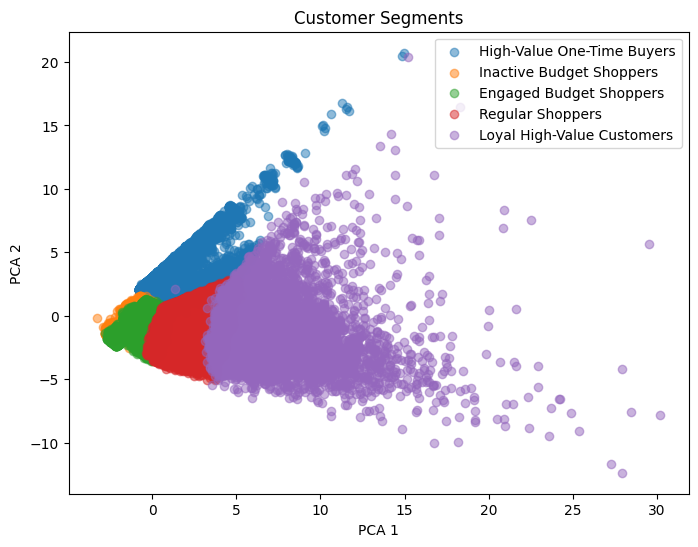

In [34]:
plt.figure(figsize=(8, 6))

for cluster in sorted(customer_features["cluster"].unique()):
    subset = customer_features[customer_features["cluster"] == cluster]
    
    plt.scatter(
        subset["pca_1"],
        subset["pca_2"],
        label=segment_name_map[cluster],
        alpha=0.5
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments")

plt.legend()
plt.show()

The PCA visualization shows that customer segments are partially separated, with some overlap between clusters. This is expected because customer behavior exists on a spectrum rather than forming perfectly distinct groups.

We observe that high-value customers form a more dispersed cluster, while low-activity customers are more concentrated and overlapping. This indicates that spending and activity level are the primary drivers of variation, while other factors such as engagement and price sensitivity contribute to finer distinctions between segments.

Overall, the clustering captures meaningful behavioral patterns even though the boundaries between segments are not sharply defined.


#### Segment Strategy Table


In [28]:
segment_strategy = pd.DataFrame([
    {
        "customer_segment": "High-Value One-Time Buyers",
        "segment_description": "Customers who purchased rarely but spent relatively more per transaction.",
        "recommended_strategy": "Reactivation campaigns with premium positioning",
        "copy_angle": "quality, exclusivity, worth coming back for"
    },
    {
        "customer_segment": "Inactive Budget Shoppers",
        "segment_description": "Low-spending customers with low engagement and long inactivity.",
        "recommended_strategy": "Win-back discounts, simple value offers, clearance promotions",
        "copy_angle": "affordable, practical, low-commitment"
    },
    {
        "customer_segment": "Engaged Budget Shoppers",
        "segment_description": "Price-sensitive customers who are still highly engaged with the brand.",
        "recommended_strategy": "Deal-focused campaigns, bundle offers, personalized sale alerts",
        "copy_angle": "value-driven, timely, deal-oriented"
    },
    {
        "customer_segment": "Regular Shoppers",
        "segment_description": "Moderately active customers with steady purchasing behavior.",
        "recommended_strategy": "Cross-sell recommendations, seasonal edits, everyday outfit suggestions",
        "copy_angle": "easy, relevant, everyday style"
    },
    {
        "customer_segment": "Loyal High-Value Customers",
        "segment_description": "Frequent, high-spending customers with more recent purchase activity.",
        "recommended_strategy": "VIP rewards, early access, premium recommendations, loyalty campaigns",
        "copy_angle": "exclusive, personalized, rewarding"
    }
])

segment_strategy

,customer_segment,segment_description,recommended_strategy,copy_angle
0,High-Value One-Time Buyers,Customers who purchased rarely but spent relat...,Reactivation campaigns with premium positioning,"quality, exclusivity, worth coming back for"
1,Inactive Budget Shoppers,Low-spending customers with low engagement and...,"Win-back discounts, simple value offers, clear...","affordable, practical, low-commitment"
2,Engaged Budget Shoppers,Price-sensitive customers who are still highly...,"Deal-focused campaigns, bundle offers, persona...","value-driven, timely, deal-oriented"
3,Regular Shoppers,Moderately active customers with steady purcha...,"Cross-sell recommendations, seasonal edits, ev...","easy, relevant, everyday style"
4,Loyal High-Value Customers,"Frequent, high-spending customers with more re...","VIP rewards, early access, premium recommendat...","exclusive, personalized, rewarding"


#### Save Outputs


In [29]:
customer_segments_path = os.path.join(PROCESSED_DIR, "customer_segments.csv")
segment_strategy_path = os.path.join(PROCESSED_DIR, "segment_strategy.csv")
cluster_summary_path = os.path.join(PROCESSED_DIR, "customer_segment_summary.csv")

customer_features.to_csv(customer_segments_path, index=False)
segment_strategy.to_csv(segment_strategy_path, index=False)
cluster_summary.to_csv(cluster_summary_path, index=False)

print(customer_segments_path)
print(segment_strategy_path)
print(cluster_summary_path)

../data/processed/hm/customer_segments.csv
../data/processed/hm/segment_strategy.csv
../data/processed/hm/customer_segment_summary.csv


In [33]:
MODEL_DIR = "../models/segmentation"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(kmeans, os.path.join(MODEL_DIR, "kmeans_customer_segments.pkl"))
joblib.dump(scaler, os.path.join(MODEL_DIR, "customer_segment_scaler.pkl"))
joblib.dump(clustering_features, os.path.join(MODEL_DIR, "clustering_features.pkl"))

['../models/segmentation/clustering_features.pkl']

#### Output Check


In [30]:
pd.read_csv(customer_segments_path).head()

,customer_id,total_transactions,unique_products,total_spend,avg_price,max_price,first_purchase_date,last_purchase_date,days_since_last_purchase,customer_lifetime_days,...,fashion_news_binary,is_active,club_member_status,fashion_news_frequency,age,age_group,cluster,customer_segment,pca_1,pca_2
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,1,1,0.012695,0.012695,0.012695,2019-07-25,2019-07-25,426,1,...,0.0,0.0,ACTIVE,NONE,49.0,Adult,1,Inactive Budget Shoppers,-2.093230,-0.994263
1,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1,1,0.044475,0.044475,0.044475,2019-10-01,2019-10-01,358,1,...,1.0,1.0,ACTIVE,Regularly,52.0,Mature,0,High-Value One-Time Buyers,0.180387,2.007445
2,0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d...,1,1,0.022017,0.022017,0.022017,2019-10-22,2019-10-22,337,1,...,0.0,0.0,ACTIVE,NONE,20.0,Gen Z,1,Inactive Budget Shoppers,-1.342126,0.156293
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,2,2,0.032847,0.016424,0.017610,2018-09-20,2020-04-11,165,570,...,1.0,1.0,ACTIVE,Regularly,32.0,Young Adult,3,Regular Shoppers,1.374438,-2.806089
4,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,2,2,0.040932,0.020466,0.025407,2020-06-21,2020-08-17,37,58,...,1.0,1.0,ACTIVE,Regularly,56.0,Mature,3,Regular Shoppers,0.624498,-1.714984
